# PGMPy Datasets API

A guided exploration of pgmpy's dataset loading subsystem:
- `list_datasets()`: Discover available datasets with rich filters
- `load_dataset()`: Load a dataset by name into a structured `Dataset` object
- `Dataset` attributes: tabular data, ground-truth DAG, expert knowledge, metadata tags

This module is the entry point for obtaining benchmark data used in causal
discovery, structure learning, and parameter estimation.

## Imports and Setup

In [74]:
%load_ext autoreload
%autoreload 2

import logging
import warnings

warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
import pgmpy.datasets as ds
import pandas as pd

In [76]:
# Use this for most notebooks.
import helpers.htutorial as htutori

htutori.config_notebook()

# Import pgmpy utilities.
import tutorials.pgmpy.pgmpy_utils as tpgpguti

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

# Convert `display` into `print()` when running outside IPython.
try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

INFO:helpers.htutorial:Setting notebook style
INFO:helpers.htutorial:Notebook signature
INFO:helpers.htutorial:numpy version=2.4.6
INFO:helpers.htutorial:matplotlib version=3.10.9


Python 3.12.13
Linux 6cd63cc7886d 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 GNU/Linux


In [77]:
import logging

logging.getLogger("httpx").setLevel(logging.WARNING)

# Part 1: Library Overview

## What problem does `pgmpy.datasets` solve?

- Provides one-line access to 47+ curated benchmark datasets for graphical models
- Eliminates the boilerplate of finding, downloading, and parsing standard datasets
- Some datasets include the true causal graph (ground truth) for supervised evaluation
- Some include expert domain knowledge (edge constraints) for causal discovery

## Key abstractions

- **Catalog**: `list_datasets()` returns a list of dataset name strings
  - Supports keyword filters: `is_discrete`, `is_continuous`, `has_ground_truth`, etc.
- **Loader**: `load_dataset(name)` returns a single `Dataset` object
- **Dataset**: A lightweight dataclass with five key fields:
  - `name` (str): Dataset identifier
  - `data` (pd.DataFrame): The actual tabular data
  - `ground_truth` (DAG or None): True causal graph (when available)
  - `expert_knowledge` (ExpertKnowledge or None): Domain edge constraints
  - `tags` (dict): Metadata (n_variables, n_samples, data types, etc.)

## How the pieces fit together

```
User -> list_datasets(is_discrete=True) -> ['college_plans', ...]
User -> load_dataset('sachs_discrete')
     -> Dataset(name='sachs_discrete',
                data=DataFrame(5400 x 11),
                ground_truth=DAG(11 nodes, 20 edges),
                tags={n_variables: 11, ...})
```

# Part 2: Primitive-by-Primitive Exploration

## Primitive 1: `list_datasets()`: The Catalog

**Mental model**: A searchable registry of all available benchmark datasets.
Returns a plain list of name strings suitable for passing to `load_dataset()`.

In [78]:
# Smallest construction: no arguments returns all 47+ datasets.
all_datasets = ds.list_datasets()
print(f"Total datasets available: {len(all_datasets)}")
print("\n".join(all_datasets))

Total datasets available: 47
abalone_continuous
abalone_mixed
adult
airfoil
algerian_forest
angrist_krueger_qob
apple_watch_fitbit
auto_mpg
blue_driver
boston_housing
cities
college_plans
contraceptive_method
cover_type
credit_approval
cystic_fibrosis
depression_coping
dropouts
dry_bean
galton_stature
goldberg
hitters
htru2
hungary_chickenpox
iq_brain_size
lead
myocardial_infarction
pima_diabetes
pittsburgh_bridges
residential_building
sachs_continuous
sachs_continuous_jittered
sachs_continuous_jittered_logscale
sachs_continuous_logscale
sachs_discrete
sachs_mixed
seoul_bike
south_german_credit
spartina
student_performance
superconductivity
tubingen
uscrime
wine_quality_red
wine_quality_red_white_mixed
wine_quality_white
yacht_hydrodynamics


In [79]:
# Filter by data type: discrete only.
discrete_ds = ds.list_datasets(is_discrete=True)
print(f"Discrete datasets ({len(discrete_ds)}): {discrete_ds}")

Discrete datasets (3): ['college_plans', 'pittsburgh_bridges', 'sachs_discrete']


In [80]:
# Filter by data type: continuous only.
continuous_ds = ds.list_datasets(is_continuous=True)
print(f"Continuous datasets ({len(continuous_ds)}): {continuous_ds[:10]}")

Continuous datasets (23): ['abalone_continuous', 'airfoil', 'angrist_krueger_qob', 'blue_driver', 'boston_housing', 'cities', 'depression_coping', 'dropouts', 'goldberg', 'hungary_chickenpox']


In [81]:
# Filter by data type: mixed (both discrete and continuous columns).
mixed_ds = ds.list_datasets(is_mixed=True)
print(f"Mixed datasets ({len(mixed_ds)}): {mixed_ds}")

Mixed datasets (22): ['abalone_mixed', 'adult', 'algerian_forest', 'apple_watch_fitbit', 'auto_mpg', 'contraceptive_method', 'cover_type', 'credit_approval', 'cystic_fibrosis', 'dry_bean', 'galton_stature', 'hitters', 'htru2', 'pima_diabetes', 'residential_building', 'sachs_mixed', 'seoul_bike', 'south_german_credit', 'student_performance', 'tubingen', 'uscrime', 'wine_quality_red_white_mixed']


In [82]:
# Filter by presence of ground truth.
with_gt = ds.list_datasets(has_ground_truth=True)
print(f"Datasets with ground truth ({len(with_gt)}): {with_gt}")

Datasets with ground truth (8): ['hungary_chickenpox', 'sachs_continuous', 'sachs_continuous_jittered', 'sachs_continuous_jittered_logscale', 'sachs_continuous_logscale', 'sachs_discrete', 'sachs_mixed', 'tubingen']


In [83]:
# Filter by number of variables.
few_vars = ds.list_datasets(n_variables=5)
print(f"Datasets with exactly 5 variables: {few_vars}")

ten_vars = ds.list_datasets(n_variables=10)
print(f"Datasets with exactly 10 variables: {ten_vars}")

Datasets with exactly 5 variables: ['angrist_krueger_qob', 'college_plans', 'galton_stature']
Datasets with exactly 10 variables: ['blue_driver']


In [84]:
# Combine multiple filters for precise selection.
rare = ds.list_datasets(is_interventional=True)
print(f"Interventional datasets ({len(rare)}): {rare}")

simulated = ds.list_datasets(is_simulated=True)
print(f"Simulated datasets ({len(simulated)}): {simulated}")

Interventional datasets (3): ['sachs_continuous_jittered', 'sachs_continuous_jittered_logscale', 'sachs_mixed']
Simulated datasets (4): ['dropouts', 'goldberg', 'lead', 'spartina']


## Primitive 2: `load_dataset()`: The Loader

**Mental model**: Given a name string from the catalog, load and return a fully
populated `Dataset` object with tabular data and optional metadata.

In [85]:
# Smallest construction: load a simple dataset.
data = ds.load_dataset("galton_stature")
print(f"Loaded dataset: {data.name}")
print(f"Object type: {type(data)}")

Loaded dataset: galton_stature
Object type: <class 'pgmpy.datasets._base.Dataset'>


In [86]:
# Inspect the object.
print(f"type(data): {type(data)}")
print(
    "dir(data) basic attributes:",
    [a for a in dir(data) if not a.startswith("_")],
)

type(data): <class 'pgmpy.datasets._base.Dataset'>
dir(data) basic attributes: ['data', 'expert_knowledge', 'ground_truth', 'name', 'tags']


In [87]:
# Try loading a different dataset.
data2 = ds.load_dataset("pima_diabetes")
print(f"Loaded: {data2.name}")
print(f"type: {type(data2)}")
print(f"dir: {[a for a in dir(data2) if not a.startswith('_')]}")

Loaded: pima_diabetes
type: <class 'pgmpy.datasets._base.Dataset'>
dir: ['data', 'expert_knowledge', 'ground_truth', 'name', 'tags']


## Primitive 3: `Dataset.data`: The Tabular Data

**Mental model**: The actual observations as a pandas DataFrame, ready for
`estimator.fit(data)`.

In [88]:
# Load the Pima diabetes dataset.
data = ds.load_dataset("pima_diabetes")

# Inspect the data field.
print(f"type: {type(data.data)}")
print(f"shape: {data.data.shape}")
print(f"columns: {list(data.data.columns)}")
print(f"dtypes:\n{data.data.dtypes}")
print("\nfirst 5 rows:")
display(data.data.head())

type: <class 'pandas.DataFrame'>
shape: (768, 9)
columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
dtypes:
Pregnancies                    int64
Glucose                        int64
BloodPressure                  int64
SkinThickness                  int64
Insulin                        int64
BMI                          float64
DiabetesPedigreeFunction     float64
Age                            int64
Outcome                     category
dtype: object

first 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [89]:
# Check basic statistics.
print(f"Missing values: {data.data.isnull().sum().sum()}")
print("Summary statistics:")
display(data.data.describe())

Missing values: 0
Summary statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


## Primitive 4: `Dataset.ground_truth`: The True Causal Graph

**Mental model**: When available, this is a `DAG` object representing the true
underlying causal structure. Used to evaluate how well a causal discovery
algorithm recovered the correct graph.

In [90]:
# Load a dataset with ground truth.
data = ds.load_dataset("sachs_discrete")

# Inspect the ground truth.
print(f"ground_truth type: {type(data.ground_truth)}")
print(f"Number of nodes: {len(data.ground_truth.nodes())}")
print(f"Number of edges: {len(data.ground_truth.edges())}")
print(f"\nNodes: {sorted(list(data.ground_truth.nodes()))}")
print(f"\nEdges: {list(data.ground_truth.edges())}")

ground_truth type: <class 'pgmpy.base.DAG.DAG'>
Number of nodes: 11
Number of edges: 20

Nodes: ['akt', 'erk', 'jnk', 'mek', 'p38', 'pip2', 'pip3', 'pka', 'pkc', 'plc', 'raf']

Edges: [('erk', 'akt'), ('mek', 'erk'), ('pip2', 'pkc'), ('pkc', 'jnk'), ('pkc', 'mek'), ('pkc', 'p38'), ('pkc', 'pka'), ('pkc', 'raf'), ('pip3', 'akt'), ('pip3', 'pip2'), ('pip3', 'plc'), ('plc', 'pip2'), ('plc', 'pkc'), ('pka', 'akt'), ('pka', 'erk'), ('pka', 'jnk'), ('pka', 'mek'), ('pka', 'p38'), ('pka', 'raf'), ('raf', 'mek')]


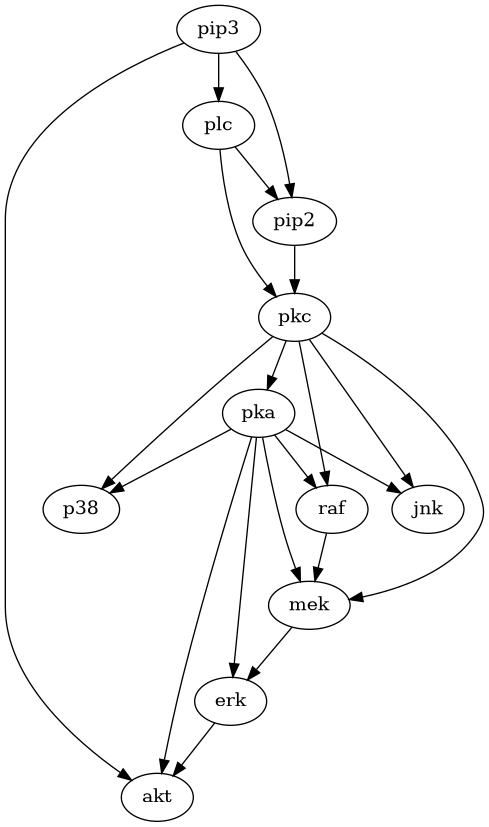

In [91]:
_ = tpgpguti.draw_pgmpy_model(data.ground_truth)

In [92]:
# Inspect the DAG: check predecessors and successors.
gt = data.ground_truth
print(f"Predecessors of 'erk': {list(gt.predecessors('erk'))}")
print(f"Successors of 'pkc': {list(gt.successors('pkc'))}")
print(f"Is 'pkc' a parent of 'jnk'?: {gt.has_edge('pkc', 'jnk')}")
print(f"Is 'jnk' a parent of 'pkc'?: {gt.has_edge('jnk', 'pkc')}")

Predecessors of 'erk': ['mek', 'pka']
Successors of 'pkc': ['jnk', 'mek', 'p38', 'pka', 'raf']
Is 'pkc' a parent of 'jnk'?: True
Is 'jnk' a parent of 'pkc'?: False


In [93]:
# Check what happens when a dataset has no ground truth.
data2 = ds.load_dataset("galton_stature")
print(f"galton_stature ground_truth: {data2.ground_truth}")
# Returns None : the field is optional.

galton_stature ground_truth: None


## Primitive 5: `Dataset.expert_knowledge`: Domain Constraints

**Mental model**: Prior knowledge about edges that must be present, must be
absent, or temporal ordering, which is used to guide causal discovery algorithms.

In [94]:
# Load a dataset with expert knowledge.
data = ds.load_dataset("sachs_discrete")

# Inspect expert knowledge.
ek = data.expert_knowledge
print(f"expert_knowledge type: {type(ek)}")
print(f"forbidden_edges: {ek.forbidden_edges}")
print(f"required_edges count: {len(ek.required_edges)}")
print(f"required_edges (sample): {list(ek.required_edges)[:5]}")
print(f"search_space: {ek.search_space}")
print(f"temporal_order: {ek.temporal_order}")

expert_knowledge type: <class 'pgmpy.causal_discovery.ExpertKnowledge.ExpertKnowledge'>
forbidden_edges: set()
required_edges count: 20
required_edges (sample): [('pkc', 'pka'), ('plc', 'pkc'), ('mek', 'erk'), ('pkc', 'jnk'), ('pkc', 'p38')]
search_space: set()
temporal_order: [[], [], []]


In [95]:
# Check dataset without expert knowledge.
data2 = ds.load_dataset("galton_stature")
print(f"galton_stature expert_knowledge: {data2.expert_knowledge}")

galton_stature expert_knowledge: None


## Primitive 6: `Dataset.tags`: Metadata Dictionary

**Mental model**: A dictionary of descriptive metadata about the dataset,
including counts, boolean flags for data type, and provenance info.

In [96]:
# Load a dataset and inspect tags.
data = ds.load_dataset("sachs_discrete")
print(f"tags type: {type(data.tags)}")

# Print each tag key-value pair.
for key, value in data.tags.items():
    print(f"  {key}: {value}")

tags type: <class 'dict'>
  name: sachs_discrete
  n_variables: 11
  n_samples: 5400
  has_ground_truth: True
  has_expert_knowledge: True
  has_missing_data: False
  has_index_col: False
  is_simulated: False
  is_interventional: False
  is_discrete: True
  is_continuous: False
  is_mixed: False
  is_ordinal: False


In [ ]:
# Compare tags across different dataset types.
sachs_tags = ds.load_dataset("sachs_discrete").tags
galton_tags = ds.load_dataset("galton_stature").tags

# Build a comparison DataFrame from the tags dictionaries.
tags_df = pd.DataFrame(
    {
        "Property": list(sachs_tags.keys()),
        "sachs_discrete": [str(sachs_tags[k]) for k in sachs_tags],
        "galton_stature": [str(galton_tags[k]) for k in sachs_tags],
    }
)
display(tags_df)

# Part 3: Composition Examples

## Example 1: List a Category, Load the First Dataset, Inspect It

Minimal workflow: discover -> load -> explore.

In [98]:
# Discover discrete datasets.
discrete = ds.list_datasets(is_discrete=True)
print(f"Discrete datasets: {discrete}")

# Load the first one.
ds1 = ds.load_dataset(discrete[0])
print(f"\nName: {ds1.name}")
print(f"Shape: {ds1.data.shape}")
print(f"Columns: {list(ds1.data.columns)}")
display(ds1.data.head())

# Print tags.
for k, v in ds1.tags.items():
    print(f"  {k}: {v}")

Discrete datasets: ['college_plans', 'pittsburgh_bridges', 'sachs_discrete']

Name: college_plans
Shape: (10318, 5)
Columns: ['sex', 'iq', 'cp', 'pe', 'ses']


,sex,iq,cp,pe,ses
0,1,1,1,1,1
1,1,1,1,1,1
2,1,1,1,1,1
3,1,1,1,1,1
4,1,1,1,1,2


  name: college_plans
  n_variables: 5
  n_samples: 10318
  has_ground_truth: False
  has_expert_knowledge: False
  has_missing_data: False
  has_index_col: False
  is_simulated: False
  is_interventional: False
  is_discrete: True
  is_continuous: False
  is_mixed: False
  is_ordinal: True


## Example 2: Filter by Ground Truth, Load, Compare Data vs Graph

In [99]:
gt_ds = ds.list_datasets(has_ground_truth=True)
print(f"Datasets with ground truth: {gt_ds}")

# Use `sachs_discrete` since some ground-truth graphs have parsing issues.
ds2 = ds.load_dataset("sachs_discrete")

print(f"Dataset: {ds2.name}")
print(f"Data shape: {ds2.data.shape}")
print(f"Ground truth nodes: {len(ds2.ground_truth.nodes())}")
print(f"Ground truth edges: {len(ds2.ground_truth.edges())}")

# Show a few rows.
display(ds2.data.head(3))

# Show the graph edges.
print(f"Edges: {list(ds2.ground_truth.edges())}")

Datasets with ground truth: ['hungary_chickenpox', 'sachs_continuous', 'sachs_continuous_jittered', 'sachs_continuous_jittered_logscale', 'sachs_continuous_logscale', 'sachs_discrete', 'sachs_mixed', 'tubingen']
Dataset: sachs_discrete
Data shape: (5400, 11)
Ground truth nodes: 11
Ground truth edges: 20


,raf,mek,plc,pip2,pip3,erk,akt,pka,pkc,p38,jnk
0,1,1,1,2,3,2,1,3,1,2,1
1,1,1,1,1,3,3,2,3,1,2,1
2,1,1,2,2,3,2,1,3,2,1,1


Edges: [('erk', 'akt'), ('mek', 'erk'), ('pip2', 'pkc'), ('pkc', 'jnk'), ('pkc', 'mek'), ('pkc', 'p38'), ('pkc', 'pka'), ('pkc', 'raf'), ('pip3', 'akt'), ('pip3', 'pip2'), ('pip3', 'plc'), ('plc', 'pip2'), ('plc', 'pkc'), ('pka', 'akt'), ('pka', 'erk'), ('pka', 'jnk'), ('pka', 'mek'), ('pka', 'p38'), ('pka', 'raf'), ('raf', 'mek')]


## Example 3: Load a Large Continuous Dataset and Summarize

In [100]:
# Find continuous datasets.
cont = ds.list_datasets(is_continuous=True)
print(f"Continuous datasets: {len(cont)}")
print(f"  {cont}")

# Load a modest-sized one.
ds3 = ds.load_dataset("airfoil")
print(f"\nDataset: {ds3.name}")
print(f"Shape: {ds3.data.shape}")
print(f"Columns: {list(ds3.data.columns)}")
display(ds3.data.describe())

Continuous datasets: 23
  ['abalone_continuous', 'airfoil', 'angrist_krueger_qob', 'blue_driver', 'boston_housing', 'cities', 'depression_coping', 'dropouts', 'goldberg', 'hungary_chickenpox', 'iq_brain_size', 'lead', 'myocardial_infarction', 'sachs_continuous', 'sachs_continuous_jittered', 'sachs_continuous_jittered_logscale', 'sachs_continuous_logscale', 'spartina', 'superconductivity', 'tubingen', 'wine_quality_red', 'wine_quality_white', 'yacht_hydrodynamics']

Dataset: airfoil
Shape: (1503, 6)
Columns: ['Frequency', 'Attack', 'Chord', 'Velocity', 'Displacement', 'Pressure']


,Frequency,Attack,Chord,Velocity,Displacement,Pressure
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011134,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000400,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002500,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.005000,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015550,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058400,140.987000


## Example 4: Use Expert Knowledge + Ground Truth Together

The Sachs dataset family includes both ground truth and expert knowledge,
making it useful for benchmarking causal discovery algorithms.

In [101]:
# Load the mixed-type Sachs dataset.
ds4 = ds.load_dataset("sachs_mixed")

print(f"Dataset: {ds4.name}")
print("Data type: discrete, continuous, or mixed?")
print(f"  is_discrete: {ds4.tags['is_discrete']}")
print(f"  is_continuous: {ds4.tags['is_continuous']}")
print(f"  is_mixed: {ds4.tags['is_mixed']}")
print(f"\nShape: {ds4.data.shape}")

# Check ground truth structure.
gt = ds4.ground_truth
print(f"\nGround truth: {gt.nodes()} -> {gt.edges()}")

# Check expert knowledge.
ek = ds4.expert_knowledge
print("\nExpert knowledge:")
print(f"  Required edges: {len(ek.required_edges)}")
print(f"  Forbidden edges: {len(ek.forbidden_edges)}")

Dataset: sachs_mixed
Data type: discrete, continuous, or mixed?
  is_discrete: False
  is_continuous: False
  is_mixed: True

Shape: (7466, 20)

Ground truth: ['erk', 'akt', 'mek', 'pip2', 'pkc', 'pip3', 'plc', 'pka', 'jnk', 'p38', 'raf'] -> [('erk', 'akt'), ('mek', 'erk'), ('pip2', 'pkc'), ('pkc', 'jnk'), ('pkc', 'mek'), ('pkc', 'p38'), ('pkc', 'pka'), ('pkc', 'raf'), ('pip3', 'akt'), ('pip3', 'pip2'), ('pip3', 'plc'), ('plc', 'pip2'), ('plc', 'pkc'), ('pka', 'akt'), ('pka', 'erk'), ('pka', 'jnk'), ('pka', 'mek'), ('pka', 'p38'), ('pka', 'raf'), ('raf', 'mek')]

Expert knowledge:
  Required edges: 20
  Forbidden edges: 0


In [102]:
# Check that the same ground truth graph is shared across all Sachs variants.
sachs_variants = [n for n in ds.list_datasets() if n.startswith("sachs")]
print(f"Sachs variants: {sachs_variants}")

gt_edges = {}
for name in sachs_variants:
    try:
        d = ds.load_dataset(name)
        gt_edges[name] = len(d.ground_truth.edges())
        print(
            f"  {name}: {d.data.shape}, GT edges: {len(d.ground_truth.edges())}"
        )
    except Exception as e:
        print(f"  {name}: ERROR - {type(e).__name__}")

# All Sachs variants share the same ground truth graph.
all_same = len(set(gt_edges.values())) == 1
print(f"\nAll variants share the same graph? {all_same}")

Sachs variants: ['sachs_continuous', 'sachs_continuous_jittered', 'sachs_continuous_jittered_logscale', 'sachs_continuous_logscale', 'sachs_discrete', 'sachs_mixed']
  sachs_continuous: (7466, 11), GT edges: 20
  sachs_continuous_jittered: (7466, 20), GT edges: 20
  sachs_continuous_jittered_logscale: (7466, 20), GT edges: 20
  sachs_continuous_logscale: (7466, 11), GT edges: 20
  sachs_discrete: (5400, 11), GT edges: 20
  sachs_mixed: (7466, 20), GT edges: 20

All variants share the same graph? True


# Part 4: API Patterns

## 1. Catalog-Load Pattern

The dominant pattern: `list_datasets()` (discover) -> `load_dataset()` (fetch).
This is similar to `sklearn.datasets.fetch_*` or PyTorch's `torchvision.datasets`.

In [103]:
# The pattern in one line.
data = ds.load_dataset(ds.list_datasets(is_discrete=True)[0])
print(f"Loaded: {data.name}")

Loaded: college_plans


## 2. Filter Criterion Pattern

Filters are keyword arguments that function as predicates on the dataset metadata.
Multiple filters combine with AND semantics.

In [104]:
# AND-combined filters: discrete AND has ground truth AND expert knowledge.
precise = ds.list_datasets(is_discrete=True, has_ground_truth=True)
print(f"Discrete datasets with ground truth: {precise}")

Discrete datasets with ground truth: ['sachs_discrete']


## 3. Dataset as a Dataclass

The `Dataset` object bundles data + metadata into one container:
- `data`: Always present (pd.DataFrame)
- `ground_truth`: Optional (DAG or None)
- `expert_knowledge`: Optional (ExpertKnowledge or None)
- `tags`: Always present (dict)

In [105]:
# Show the dataclass structure via a print.
print(ds.load_dataset("boston_housing"))

Dataset(name=boston_housing, 
 data=DataFrame of size: (506, 14), 
 expert_knowledge=None, 
 ground_truth=None, 
 tags={'name': 'boston_housing', 'n_variables': 14, 'n_samples': 506, 'has_ground_truth': False, 'has_expert_knowledge': False, 'has_missing_data': False, 'has_index_col': False, 'is_simulated': False, 'is_interventional': False, 'is_discrete': False, 'is_continuous': True, 'is_mixed': False, 'is_ordinal': False})
